# 05 · Gaussiano multivariante por régimen

Ajusta una normal multivariante independiente por régimen con shrinkage de Ledoit-Wolf, y documenta por qué la covarianza muestral no sirve aquí.

**Entradas**

- `data/processed/ventanas.npz`

**Salidas**

- `models/generadores/gaussiano/ (modelo.pkl o .keras, historial.csv, meta.json)`
- `data/synthetic/gaussiano.npz`
- `results/figures/covarianza_gaussiano.png`

**Tiempo estimado:** ~10 min en CPU (el shrinkage sobre 1.201 dimensiones domina).

**Independencia.** Este notebook solo lee `data/processed/ventanas.npz` (notebook 02) y solo escribe en `models/generadores/gaussiano/` y `data/synthetic/gaussiano.npz`. No depende de ningún otro notebook de generador ni de sus salidas, de modo que los notebooks 04 a 10 pueden ejecutarse en paralelo y en cualquier orden por distintas personas.

In [16]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import ventanas

part = ventanas.cargar_procesado()
train, val, test = part.train, part.val, part.test
print(train, val, test, sep="\n")

Conjunto(n=3696, X=(3696, 60, 20), 1970-01-01 a 1970-01-01)
Conjunto(n=672, X=(672, 60, 20), 1970-01-01 a 1970-01-01)
Conjunto(n=1052, X=(1052, 60, 20), 1970-01-01 a 1970-01-01)


In [18]:
from src import regimenes
from src.generadores import base

v = config.ventanas()
n_regimenes = config.n_regimenes()

bloque_train = ventanas.empaquetar(train)
print("bloque de train:", bloque_train.shape, "· d esperada:", ventanas.dimension_bloque(v))
regimenes.distribucion(train.y_reg, n_regimenes)

bloque de train: (3696, 1201) · d esperada: 1201


,muestras,porcentaje
regimen,,
0,2019,54.63
1,1090,29.49
2,587,15.88


## El problema real: covarianza en alta dimensión

Es el generador con el que el profesor abre el taller. Estima media y covarianza
del bloque conjunto y muestrea de una normal multivariante; aquí se añade el
condicionamiento ajustando un modelo independiente por régimen.

La dificultad es de tamaño muestral. El bloque tiene 1.201 dimensiones y el tramo
de entrenamiento apenas unos miles de ventanas, que además se solapan 59 de cada 60
días: el número de observaciones **efectivamente independientes** es mucho menor
que el nominal. En la clase de crisis quedan unos cientos de ventanas que
corresponden a un puñado de episodios históricos.

Con `n < d` la covarianza muestral es singular por construcción: tiene a lo sumo
rango `n-1`. Muestrear de ella confina las muestras al subespacio que generan los
datos de entrenamiento, o directamente falla al factorizar. Por eso el estimador
por defecto es el **shrinkage de Ledoit-Wolf**, que la contrae hacia una diagonal
escalada con un peso óptimo estimado de los propios datos.

Limitación estructural: este generador no puede reproducir colas gruesas ni
asimetría, porque todo lo que produce es gaussiano. Esa limitación es informativa,
no un defecto a corregir: cuantifica cuánto de la mejora del downstream se explica
solo por reproducir medias y correlaciones.

In [19]:
generador = base.instanciar(
    "gaussiano",
    n_regimenes=n_regimenes,
    estimador="ledoit_wolf",
    transformar_vol=True,
)

generador.fit(bloque_train, train.y_reg)
generador

TypeError: GaussianoCondicional.__init__() got an unexpected keyword argument 'transformar_vol'

## Por qué no la covarianza muestral

Se ajusta también con el estimador `muestral` para dejar constancia numérica del
problema. El número de condición y el autovalor mínimo dicen cuán degenerada queda
la covarianza; la comparación de ambos estimadores es la tabla que justifica la
elección en el informe.

In [ ]:
muestral = base.instanciar(
    "gaussiano",
    n_regimenes=n_regimenes,
    estimador="muestral",
    transformar_vol=True,
)

muestral.fit(bloque_train, train.y_reg)

comparacion = pd.concat(
    {
        "ledoit_wolf": generador.historial.set_index("regimen")[
            ["n_muestras", "numero_condicion", "autovalor_minimo", "saltos_cholesky"]
        ],
        "muestral": muestral.historial.set_index("regimen")[
            ["n_muestras", "numero_condicion", "autovalor_minimo", "saltos_cholesky"]
        ],
    },
    axis=1,
)

comparacion

Régimen 1: 1090 muestras para 1201 dimensiones. La covarianza muestral es singular; el shrinkage es obligatorio aquí.
Régimen 2: 587 muestras para 1201 dimensiones. La covarianza muestral es singular; el shrinkage es obligatorio aquí.


ledoit_wolf                                                    \
         n_muestras numero_condicion autovalor_minimo saltos_cholesky   
regimen                                                                 
0              2019      7025.161776         0.010231               0   
1              1090      4324.523193         0.034387               0   
2               587      1427.449511         0.269242               0   

          muestral                                                    
        n_muestras numero_condicion autovalor_minimo saltos_cholesky  
regimen                                                               
0             2019     1.414986e+06         0.000052               0  
1             1090     1.779438e+06         0.000087               0  
2              587     1.738199e+06         0.000248               0

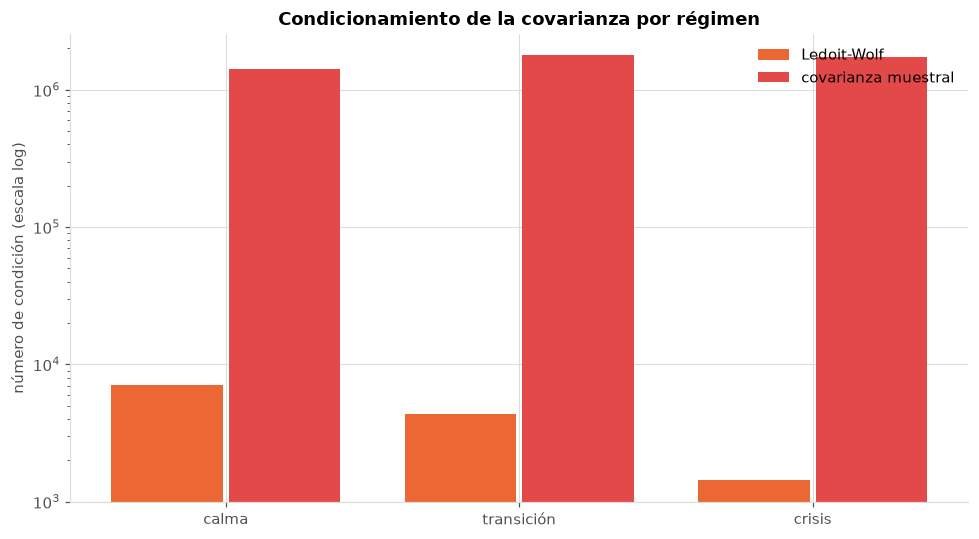

In [ ]:
fig, eje = plt.subplots()

posiciones = np.arange(n_regimenes)
eje.bar(posiciones - 0.2, generador.historial["numero_condicion"], width=0.38,
        color=viz.color("gaussiano"), label="Ledoit-Wolf")
eje.bar(posiciones + 0.2, muestral.historial["numero_condicion"], width=0.38,
        color=viz.PALETA[7], label="covarianza muestral")

eje.set_yscale("log")
eje.set_xticks(posiciones)
eje.set_xticklabels(["calma", "transición", "crisis"][:n_regimenes])
eje.set_ylabel("número de condición (escala log)")
eje.set_title("Condicionamiento de la covarianza por régimen")
eje.legend()
viz.guardar(fig, "covarianza_gaussiano")

## Convergencia

Tampoco hay curva de pérdida: nada se optimiza por gradiente. El diagnóstico
equivalente es el condicionamiento de la covarianza estimada en cada régimen. El
eje horizontal es el índice de régimen.

Un número de condición enorme señala que el muestreo queda confinado a un
subespacio de dimensión mucho menor que 1.201, es decir, que las muestras
sintéticas son combinaciones casi lineales de las de entrenamiento. Los saltos de
Cholesky cuentan cuántas veces hubo que aumentar la diagonal para poder factorizar:
cualquier valor distinto de cero es un aviso.

,epoca,regimen,n_muestras,dimension,numero_condicion,autovalor_minimo,saltos_cholesky
0,0,0,2019,1201,7025.161776,0.010231,0
1,1,1,1090,1201,4324.523193,0.034387,0
2,2,2,587,1201,1427.449511,0.269242,0


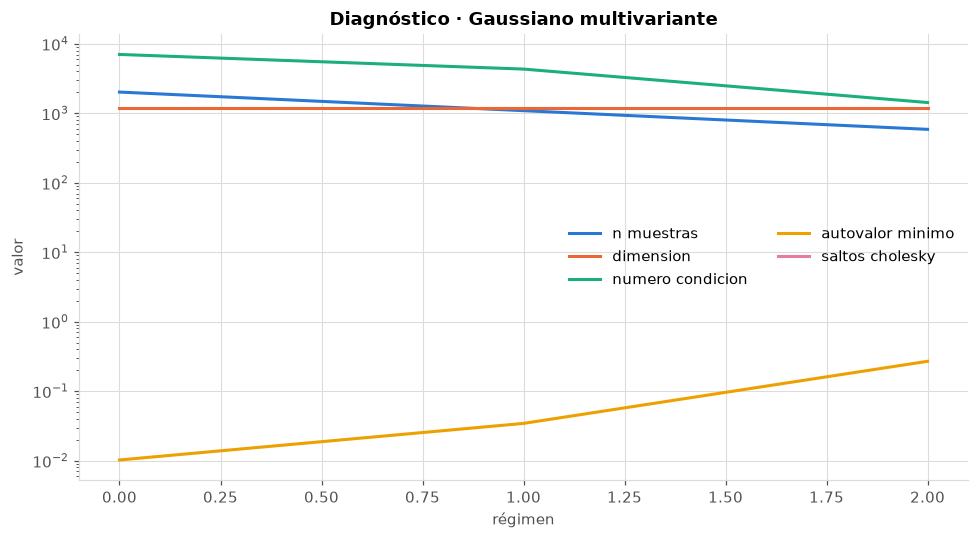

In [ ]:
fig, eje = plt.subplots()
viz.curva_convergencia(
    generador.historial.drop(columns="regimen"),
    "Diagnóstico · " + generador.etiqueta,
    eje=eje,
)
eje.set_xlabel("régimen")
eje.set_yscale("log")
viz.guardar(fig, "convergencia_gaussiano")

generador.historial

## Inspección visual

Proyección PCA de reales y sintéticos, con la PCA ajustada **solo con los reales**
para que los ejes describan la estructura del mercado y no la del generador.

Es la comprobación más rápida y la que detecta los dos fallos gruesos: si la nube
sintética no cubre la real, el generador ha colapsado a un modo; si la desborda
ampliamente, está inventando configuraciones de mercado que nunca ocurrieron.

Se mira el régimen de crisis porque es el que tiene menos datos reales y, por
tanto, donde el generador tiene más margen para desviarse.

reales de crisis: 587 · sintéticos generados: 600


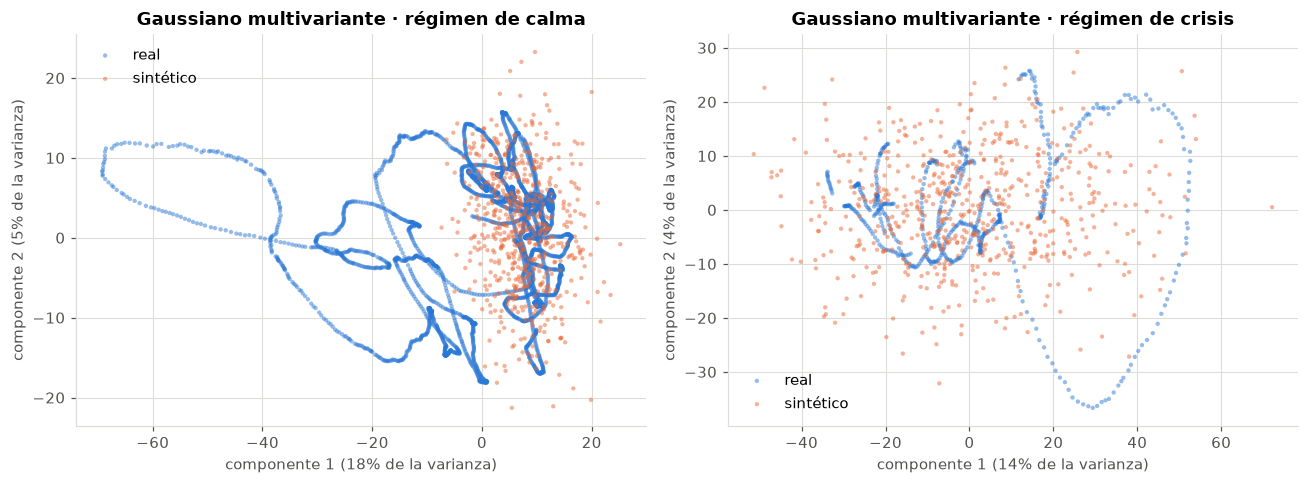

In [ ]:
CRISIS = n_regimenes - 1

muestra_crisis = generador.generate(600, regimen=CRISIS)
reales_crisis = bloque_train[train.y_reg == CRISIS]

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
viz.real_vs_sintetico(bloque_train, generador.generate(600, regimen=0),
                      "{} · régimen de calma".format(generador.etiqueta), eje=ejes[0])
viz.real_vs_sintetico(reales_crisis, muestra_crisis,
                      "{} · régimen de crisis".format(generador.etiqueta), eje=ejes[1])
fig.tight_layout()
viz.guardar(fig, "pca_" + generador.nombre)

print("reales de crisis:", len(reales_crisis), "· sintéticos generados:", len(muestra_crisis))

## Banco de muestras

Se genera un banco uniforme por régimen y se exporta a `data/synthetic/`. La mezcla
concreta de cada dataset la decide el notebook 11 muestreando de este banco, no
volviendo a invocar al generador: así el barrido no necesita tener los siete
modelos cargados en memoria y dos ejecuciones del notebook 12 usan exactamente las
mismas muestras sintéticas.

El banco es uniforme —no replica el desbalance real— porque la política de reparto
es un grado de libertad del experimento y se aplica después.

In [ ]:
MUESTRAS_POR_REGIMEN = 4000

reparto = {k: MUESTRAS_POR_REGIMEN for k in range(n_regimenes)}
bloques_sint, y_sint = generador.generate_dataset(reparto)

print(
    "banco:",
    bloques_sint.shape,
    "· etiquetas:",
    np.bincount(y_sint, minlength=n_regimenes),
)

filas_vol = []

for k in range(n_regimenes):
    vol_real = bloque_train[train.y_reg == k, -1]
    vol_sint = bloques_sint[y_sint == k, -1]

    filas_vol.append(
        {
            "regimen": k,
            "media_real": vol_real.mean(),
            "media_sintetica": vol_sint.mean(),
            "desv_real": vol_real.std(),
            "desv_sintetica": vol_sint.std(),
            "frac_no_positiva": (vol_sint <= 0).mean(),
        }
    )

diagnostico_vol = pd.DataFrame(filas_vol).set_index("regimen")

if (bloques_sint[:, -1] <= 0).any():
    raise RuntimeError(
        "El banco gaussiano contiene volatilidades no positivas."
    )

diagnostico_vol.round(4)

banco: (12000, 1201) · etiquetas: [4000 4000 4000]
rango de valores: -8.94 · 9.47 (referencia real: -10.27 · 11.4 )


## Persistencia

`guardar()` deja el modelo, la curva de convergencia y los metadatos en
`models/generadores/`. Es lo que permite que el resto del grupo salte directamente
al análisis sin reentrenar nada.

In [ ]:
ruta_muestras = generador.exportar_muestras(bloques_sint, y_sint)
ruta_modelo = generador.guardar()

print("muestras:", ruta_muestras)
print("modelo:  ", ruta_modelo)
pd.Series(generador.resumen_convergencia()).round(4)

muestras: C:\Users\Fernando Dapena T\Desktop\Taller B5-T1\TALLER_GENERATIVOS\data\synthetic\gaussiano.npz
modelo:   C:\Users\Fernando Dapena T\Desktop\Taller B5-T1\TALLER_GENERATIVOS\models\generadores\gaussiano


final_epoca                  2.0000
final_regimen                2.0000
final_n_muestras           587.0000
final_dimension           1201.0000
final_numero_condicion    1427.4495
final_autovalor_minimo       0.2692
final_saltos_cholesky        0.0000
dtype: float64

## Salidas generadas

In [ ]:
from pathlib import Path

salidas = [
    src.DIR_MODELOS_GEN / "gaussiano" / "meta.json",
    src.DIR_MODELOS_GEN / "gaussiano" / "historial.csv",
    src.DIR_SINTETICO / "gaussiano.npz",
    src.DIR_FIGURAS / "convergencia_gaussiano.png",
    src.DIR_FIGURAS / "pca_gaussiano.png",
    src.DIR_FIGURAS / "covarianza_gaussiano.png",
]

for ruta in salidas:
    ruta = Path(ruta)
    marca = "ok" if ruta.exists() else "--"
    print("[{}] {}".format(marca, ruta.relative_to(src.RAIZ)))


[ok] models\generadores\gaussiano\meta.json
[ok] models\generadores\gaussiano\historial.csv
[ok] data\synthetic\gaussiano.npz
[ok] results\figures\convergencia_gaussiano.png
[ok] results\figures\pca_gaussiano.png
[ok] results\figures\covarianza_gaussiano.png
